# Bulk-crystal CXR — analysis driver

Thin driver for the Monte-Carlo CXR pipeline; the heavy lifting lives in `src/`:

- **`cxr_sweep.py`** — a parameter `Sweep` (each parameter a single value *or* a
  range) expanded into cases.
- **`cxr_run.py`** — run the cases with checkpointing + per-chunk feedback.
- **`cxr_results.py`** — post-processing, the `best_azimuth` reduction, the stats table.
- **`cxr_plots.py`** — all the figures.
- **`cxr_montecarlo.py` / `timepix_response.py`** — the physics + detector model.

Set everything in the **PARAMETERS** cell, then run top to bottom.

In [1]:
# imports: src/ on the path, then the analysis modules (run from the repo root)
import sys

sys.path.insert(0, "src")

# Interactive click-through viewer (browse) needs the ipympl backend. For a clean
# PDF export (export_pdf.py), switch this to `%matplotlib inline` -- browse() then
# falls back to drawing every tilt stacked, so all the figures still render.
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from cxr_sweep import Sweep, build_cases, geometry_table
from cxr_results import Settings, records, best_azimuth, show_summary, filter_results
from cxr_plots import (
    browse,
    plot_by_energy,
    plot_peak_vs_tilt,
    stream_chunk,
    plot_timepix_efficiency,
    plot_timepix_detected,
    plot_timepix_poisson,
    plot_heatmaps,
    plot_full_spectrum,
)
from cxr_run import run_sweep

Using GPU


In [ ]:
# ============================================================================
#  PARAMETERS -- each physical quantity is a SINGLE VALUE (fixed) or a
#  LIST/ARRAY (swept). build_cases takes the Cartesian product over the swept
#  ones; nothing else needs to change to switch a parameter between fixed and
#  swept.
# ============================================================================

settings = Settings(
    beam_current_na=5.0,
    n_electrons=300,  # transport electrons per line spectrum
    n_electrons_brem=100,  # transport electrons per background
    apply_detector_qe=True,
    convolve_with_det=False,
    brem_source="mc",  # "mc" | "external" | "none"
)

# When tilt_azim_deg is swept, collapse it: for each (polar tilt, energy) keep
# only the azimuth with the highest spectral peak max(spectrum). False -> show
# every azimuth.
COLLAPSE_AZIMUTH = True

# Material Choices:
# "hopg" | "diamond" | "silicon" | "ptse2"
# "mose2" | "wse2" | "hfse2" | "ws2"
MATERIAL = "silicon"

In [3]:
match MATERIAL:
    case "hopg":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=17e4,  # 17 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 20, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "diamond":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=10e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 3500.0, 2.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "silicon":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "mose2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "wse2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-85, -0.1, 15),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "ptse2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-85, -0.1, 15),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "zrse2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "ws2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "mos2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

In [4]:
# build the case list and preview the geometry
cases = build_cases(sweep, settings.n_electrons, settings.n_electrons_brem)
print(f"{len(cases)} cases across {len({c['name'] for c in cases})} configs")
display(geometry_table(cases))

1350 cases across 450 configs


,config,refl,t [um],polar [deg],azim [deg],energies [keV],line grid,brem grid,theta_obs [deg],dOmega [sr]
0,PtSe2 1um pol=-89 az=-85,20,1.0,-89.0,-85.00,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
1,PtSe2 1um pol=-89 az=-78.9357,20,1.0,-89.0,-78.94,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
2,PtSe2 1um pol=-89 az=-72.8714,20,1.0,-89.0,-72.87,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
3,PtSe2 1um pol=-89 az=-66.8071,20,1.0,-89.0,-66.81,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
4,PtSe2 1um pol=-89 az=-60.7429,20,1.0,-89.0,-60.74,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
...,...,...,...,...,...,...,...,...,...,...
445,PtSe2 1um pol=89 az=-24.3571,20,1.0,89.0,-24.36,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
446,PtSe2 1um pol=89 az=-18.2929,20,1.0,89.0,-18.29,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
447,PtSe2 1um pol=89 az=-12.2286,20,1.0,89.0,-12.23,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239
448,PtSe2 1um pol=89 az=-6.16429,20,1.0,89.0,-6.16,"[30.0, 45.0, 60.0]",0.05-3.497 keV @ 3 eV,0-59.975 keV @ 25 eV,90.0,0.001239


In [5]:
results = {}

try:
    run_sweep(
        cases,
        results,
        on_chunk=lambda batch: stream_chunk(
            results, batch, settings, collapse_azimuth=COLLAPSE_AZIMUTH
        ),
    )
except EOFError:
    print("EOF Error. I think this means the script has already processed all data")

# The streamed tables print live above; click through the 2x2 best-azimuth plots
# (one figure per polar tilt) here once the run is done.
browse(filter_results(results, cases), settings, kind="chunk")

resumed 1350 ptse2 cases from checkpoints/ptse2.pkl
0 of 1350 cases to run (1350 cached)

=== cached: 1 um, tilt -89 deg (already computed) ===
window-QE applied, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0    PtSe2       1um       -89.0         -60.7     30.0    1091.0   
1    PtSe2       1um       -89.0         -60.7     45.0    1310.0   
2    PtSe2       1um       -89.0         -60.7     60.0    1481.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.12    0.24        218.0       7054.4        7272.4  
1            0.10    0.26        205.0       6769.7        6974.8  
2            0.09    0.30        207.0       7986.3        8193.3


=== cached: 1 um, tilt -82.8621 deg (already computed) ===
window-QE applied, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0    PtSe2       1um       -82.9          -6.2     30.0    1010.0   
1    PtSe2       1um       -82.9          -6.2     45.0    1361.0   
2    PtSe2       1um       -82.9          -6.2     60.0    1691.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.21    0.11        508.0      25564.5       26072.5  
1            0.16    0.11        428.1      20748.0       21176.1  
2            0.14    0.17        421.9      18100.8       18522.8


=== cached: 1 um, tilt -76.7241 deg (already computed) ===
window-QE applied, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


...

config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0    PtSe2       1um        82.9         -12.2     45.0    1280.0   
1    PtSe2       1um        82.9          -6.2     60.0    1334.0   
2    PtSe2       1um        82.9          -0.1     30.0    1052.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.11    0.16        178.4      14181.9       14360.3  
1            0.08    0.10        137.5      16796.9       16934.4  
2            0.07    0.07        128.5      23242.3       23370.8


=== cached: 1 um, tilt 89 deg (already computed) ===
window-QE applied, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0    PtSe2       1um        89.0         -24.4     60.0    1322.0   
1    PtSe2       1um        89.0          -6.2     45.0    1361.0   
2    PtSe2       1um        89.0          -0.1     30.0    1076.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.04    0.12         70.7       7520.3        7591.0  
1            0.05    0.12         87.3       8720.8        8808.2  
2            0.04    0.06         66.5      15161.8       15228.3

0 cases in 0 s


Output()

/home/aamador/dev/cxr_model/src/cxr_results.py:280: PeakPropertyWarning: some peaks have a prominence of 0
  w_samp = float(peak_widths(spec, [idx], rel_height=0.5)[0][0])
/home/aamador/dev/cxr_model/src/cxr_results.py:280: PeakPropertyWarning: some peaks have a width of 0
  w_samp = float(peak_widths(spec, [idx], rel_height=0.5)[0][0])


window-QE applied, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
   material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0     PtSe2       1um       -89.0         -60.7     30.0    1091.0   
1     PtSe2       1um       -89.0         -60.7     45.0    1310.0   
2     PtSe2       1um       -89.0         -60.7     60.0    1481.0   
3     PtSe2       1um       -82.9          -6.2     30.0    1010.0   
4     PtSe2       1um       -82.9          -6.2     45.0    1361.0   
..      ...       ...         ...           ...      ...       ...   
85    PtSe2       1um        82.9          -6.2     60.0    1334.0   
86    PtSe2       1um        82.9          -0.1     30.0    1052.0   
87    PtSe2       1um        89.0         -24.4     60.0    1322.0   
88    PtSe2       1um        89.0          -6.2     45.0    1361.0   
89    PtSe2       1um        89.0          -0.1     30.0    1076.0   

                                                                    
   peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0             0.12    0.24        218.0       7054.4        7272.4  
1             0.10    0.26        205.0       6769.7        6974.8  
2             0.09    0.30        207.0       7986.3        8193.3  
3             0.21    0.11        508.0      25564.5       26072.5  
4             0.16    0.11        428.1      20748.0       21176.1  
..             ...     ...          ...          ...           ...  
85            0.08    0.10        137.5      16796.9       16934.4  
86            0.07    0.07        128.5      23242.3       23370.8  
87            0.04    0.12         70.7       7520.3        7591.0  
88            0.05    0.12         87.3       8720.8        8808.2  
89            0.04    0.06         66.5      15161.8       15228.3  

[90 rows x 11 columns]

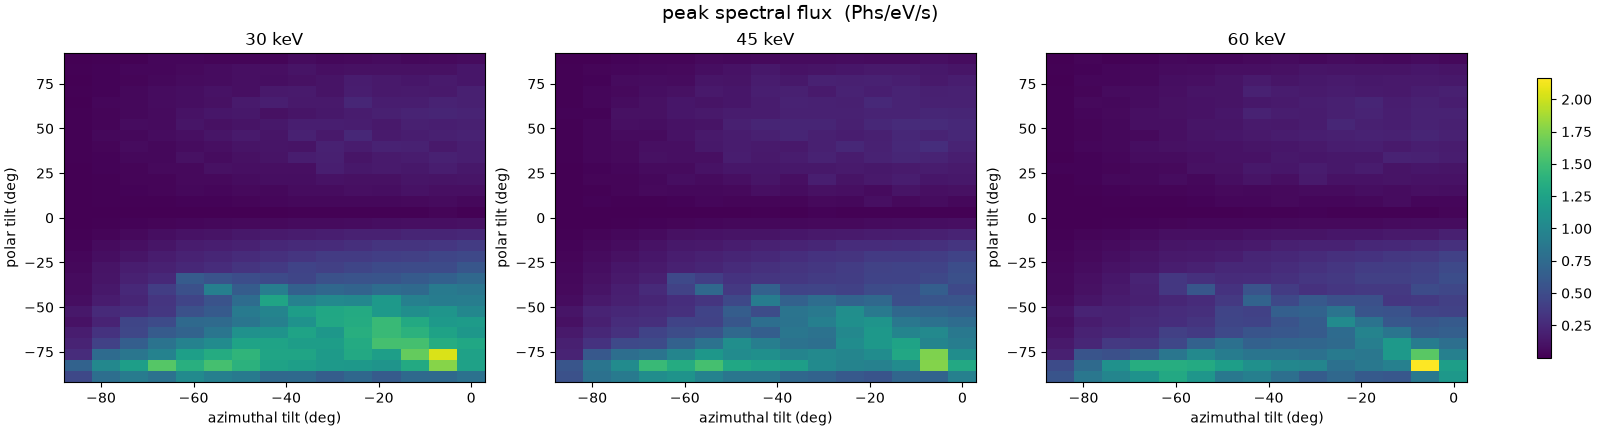

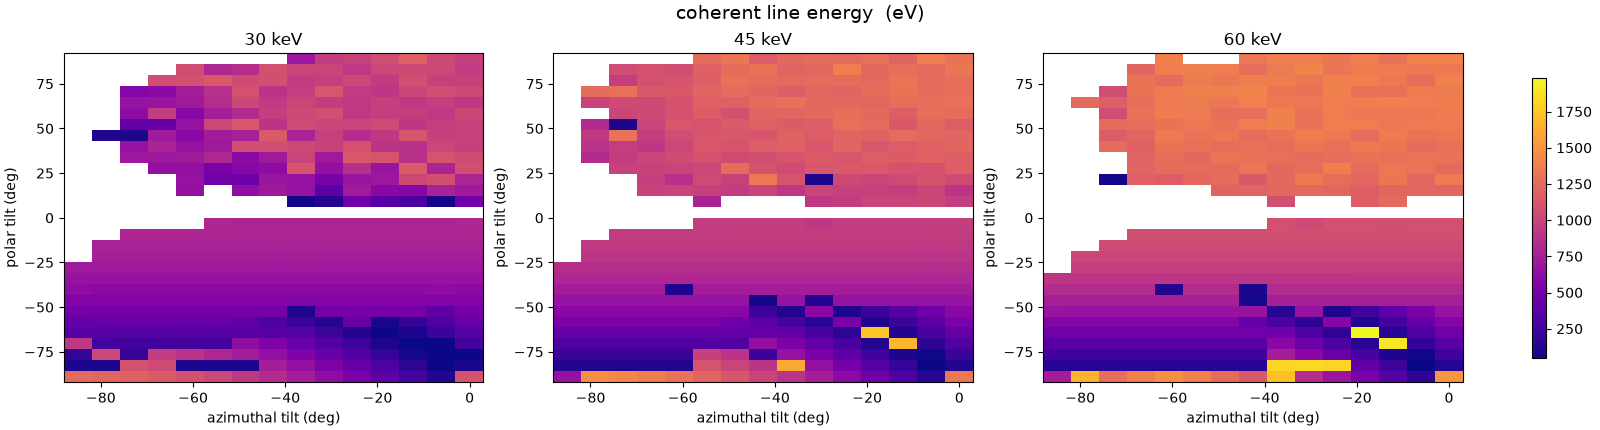

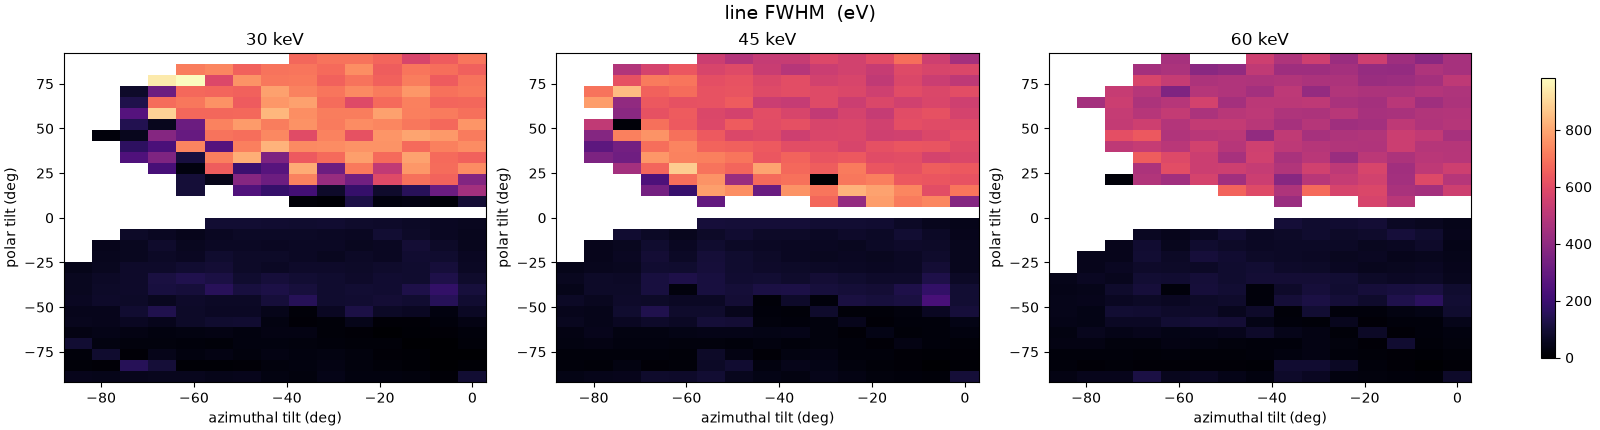

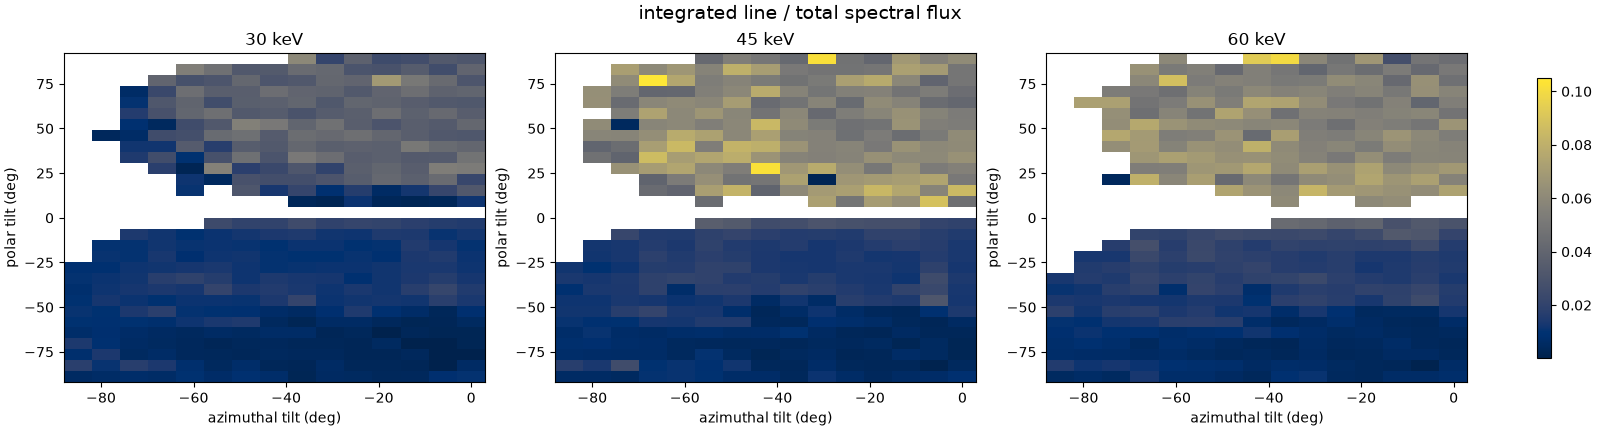

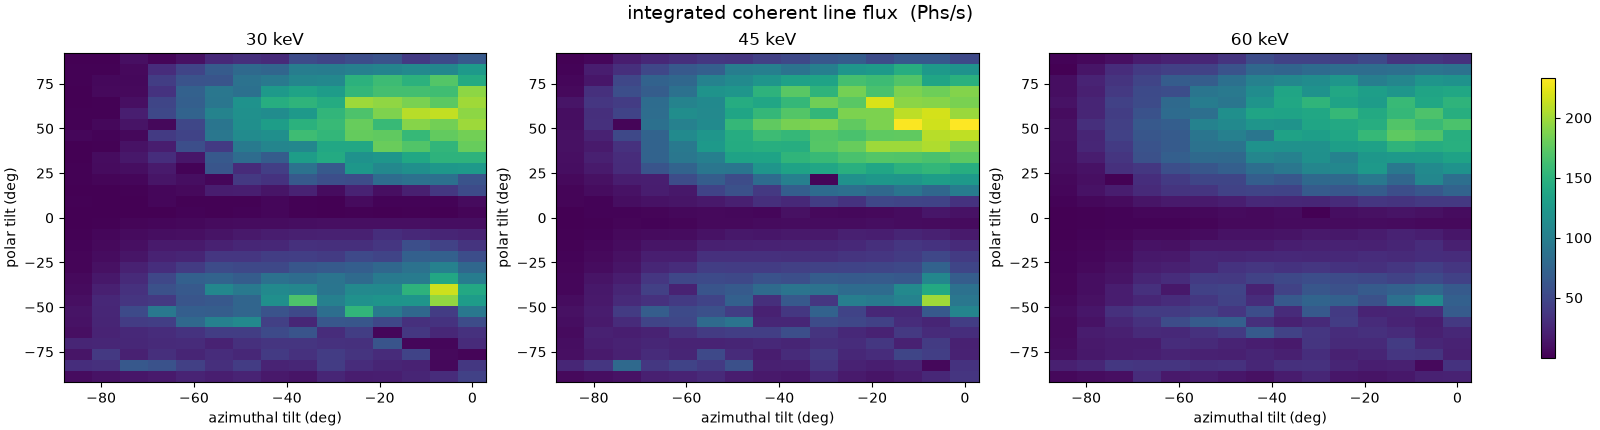

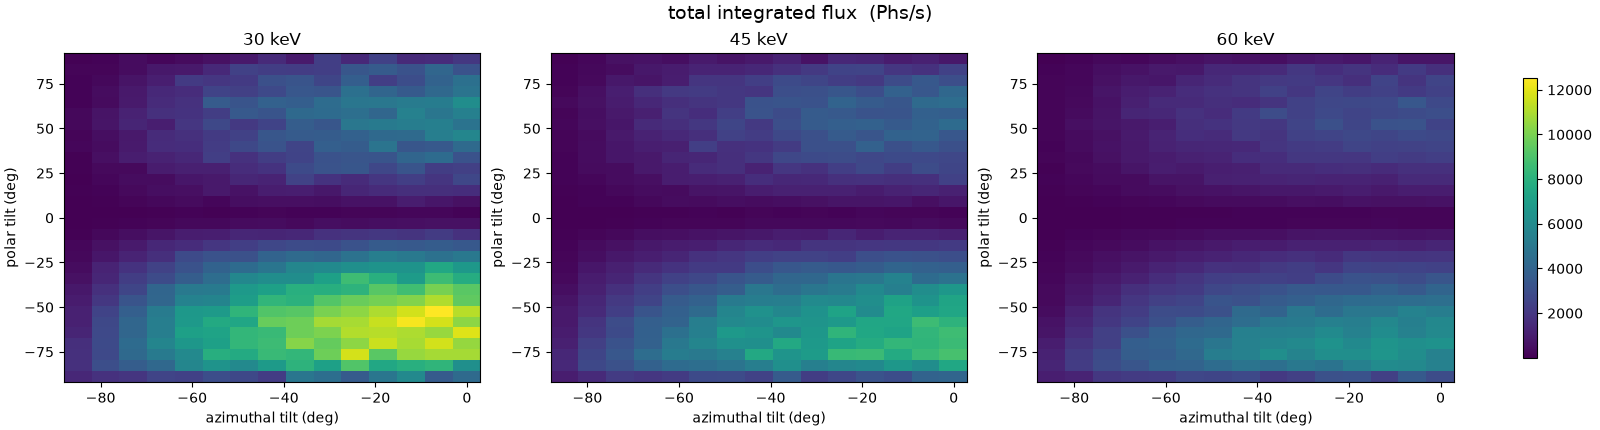

In [6]:
# Photon-counting stats. best_azimuth collapses the azimuth sweep to one row per
# (polar tilt, energy); set COLLAPSE_AZIMUTH=False above for every azimuth.
res = filter_results(results, cases)  # dict, current sweep only

plot_heatmaps(
    res, settings, cases=cases, line_metric="prominence"
)  # dominant line -> smoother maps

recs = best_azimuth(records(res)) if COLLAPSE_AZIMUTH else records(res)
show_summary(recs, settings)  # list in

## Timepix3 detector response

Push the intrinsic spectra through a forward model of the actual 2×2 Timepix3
(Si sensor): photoabsorption → charge sharing → per-pixel threshold counting →
ToT energy noise → Poisson statistics (`timepix_response.py`). The ~1.9 keV
counting threshold sits above much of the MoSe₂ signal, so expect strong sub-2
keV suppression and a charge-loss low-energy tail.

> **⚠ Set `TPX_THICKNESS_UM` / `TPX_BIAS_V` to the real quad values** —
> σ_diff ∝ 1/√(bias) is the single most sensitive knob.

Output()

Output()

Output()

/home/aamador/dev/cxr_model/src/cxr_feranchuk_spence.py:302: RuntimeWarning: divide by zero encountered in divide
  lam = HC_EV_ANG / photon_E_eV
/home/aamador/dev/cxr_model/src/cxr_plots.py:284: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(xmin, xmax)   # span the full brem grid (to the beam energy)


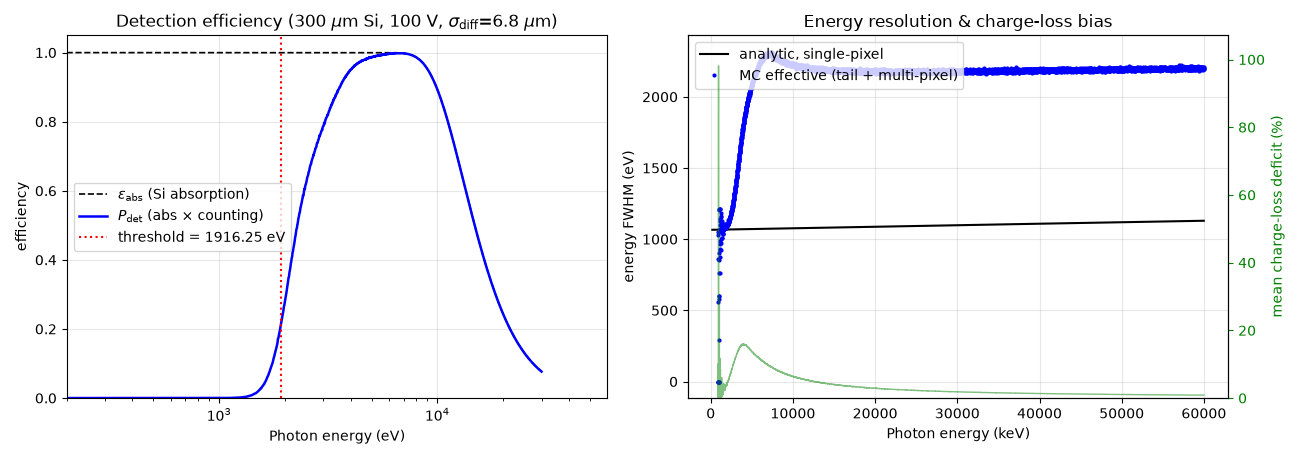

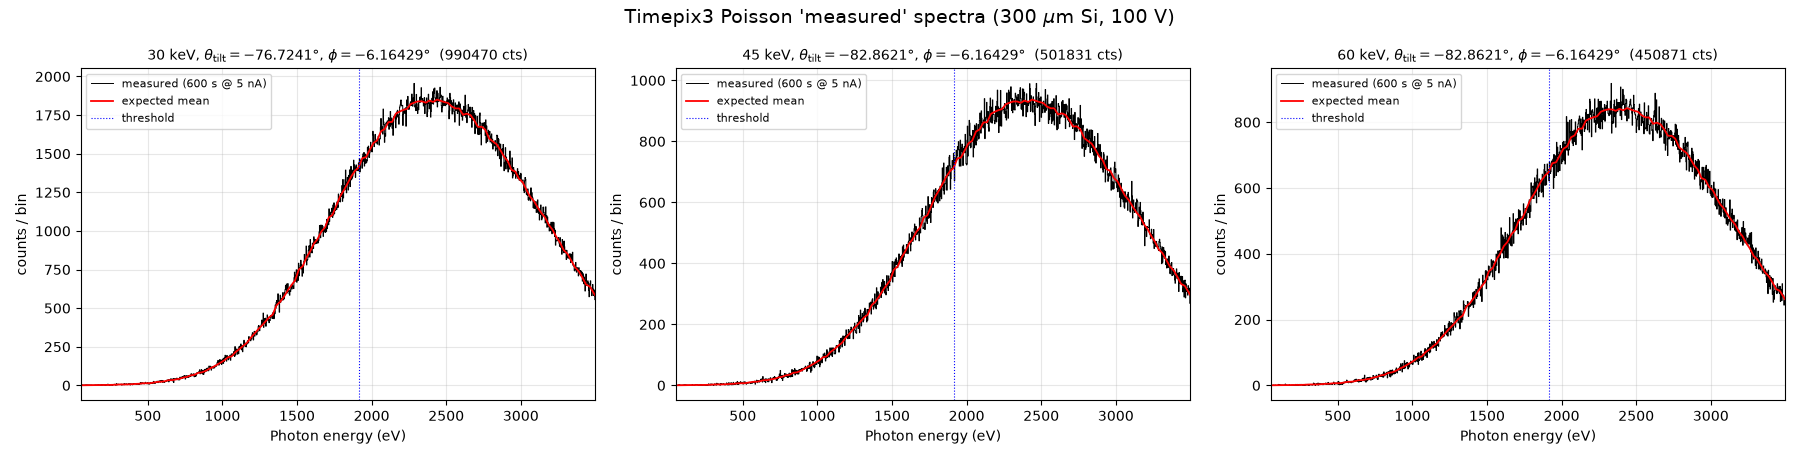

In [7]:
# Timepix3 forward-model figures. Hardware is a PLACEHOLDER -- set to the real
# quad values.
TPX_THICKNESS_UM = 300.0  ### FILL IN -- Si sensor thickness [um]
TPX_BIAS_V = 100.0  ### FILL IN -- applied bias [V]
res = filter_results(results, cases)  # current sweep only

# single-figure diagnostics (left as-is -- not many of these)
plot_timepix_efficiency(thickness_um=TPX_THICKNESS_UM, bias_v=TPX_BIAS_V)
plot_timepix_poisson(
    res,
    settings,
    integration_s=600.0,
    thickness_um=TPX_THICKNESS_UM,
    bias_v=TPX_BIAS_V,
)

# Click-through viewers -- one interactive figure each, paged by polar tilt.
# (Under %matplotlib inline these fall back to every tilt stacked, for the PDF.)
browse(
    res,
    settings,
    kind="timepix",  # Timepix detected (solid) vs incident (dotted), log
    thickness_um=TPX_THICKNESS_UM,
    bias_v=TPX_BIAS_V,
)
browse(res, settings, kind="by_energy")  # intrinsic | detector-convolved line spectra
browse(res, settings, kind="full")  # full measured range out to the beam energy, log